# Engenharia de ML e MLOps — Breast Cancer

Notebook **orquestra** o pacote em `src/breast_cancer_mlops/` (exigência da disciplina). O detalhamento frente à rubrica está em **`RELATORIO_TECNICO.md`**.

**Ordem:** dados → MLflow → t-SNE (exploração) → avaliação teste → drift → latência/lote → **gráficos + Streamlit** → API / `mlflow ui` (opcional).

**CI:** pushes e PRs nas branches padrão executam `.github/workflows/ci.yml` (pytest).

In [1]:
import os
import sys
from pathlib import Path

_here = Path.cwd()
_candidates = [_here, _here / "Operacionalização de Modelos com MLOps"]
ROOT = next((p for p in _candidates if (p / "src" / "breast_cancer_mlops" / "train.py").is_file()), None)
if ROOT is None:
    raise SystemExit("Defina o cwd na pasta do projeto (onde estão src/breast_cancer_mlops/).")
os.chdir(ROOT)
_src = ROOT / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))
print("cwd:", ROOT)

cwd: d:\programacao\FACULDADE\Fundamentos de Machine Learning com Scikit-Learn\Operacionalização de Modelos com MLOps


## Dependências

In [2]:
%pip install -q -e .

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

## 1. Dados: perfil, viés e splits (treino / validação / teste)
Fontes: CSV local, `BREAST_CANCER_CSV`, `data/breast-cancer.csv`, Kaggle ou fallback `sklearn.datasets`.

In [3]:
import json

from breast_cancer_mlops.data_prep import (
    bias_class_imbalance_summary,
    data_quality_report,
    ensure_or_create_splits,
    load_dataframe,
    preprocess,
    project_root,
)

ROOT = project_root()
df = load_dataframe()
X, y = preprocess(df)
profile = {"quality": data_quality_report(X, y), "bias": bias_class_imbalance_summary(y)}
(ROOT / "artifacts" / "data_profile").mkdir(parents=True, exist_ok=True)
with open(ROOT / "artifacts" / "data_profile" / "data_profile.json", "w", encoding="utf-8") as f:
    json.dump(profile, f, indent=2, default=str)
print(json.dumps(profile, indent=2, default=str))

X_train, X_val, X_test, y_train, y_val, y_test, feature_names = ensure_or_create_splits(ROOT)
X_train = X_train[feature_names]
X_val = X_val[feature_names]
X_test = X_test[feature_names]

{
  "quality": {
    "n_samples": 569,
    "n_features": 30,
    "total_missing_cells": 0,
    "features_with_any_missing": 0,
    "outlier_cells_iqr_rule": 608,
    "high_correlation_pairs_abs_gt_0_9": 21,
    "class_distribution": {
      "0": 0.6274,
      "1": 0.3726
    },
    "class_counts": {
      "0": 357,
      "1": 212
    }
  },
  "bias": {
    "minority_class_ratio": 0.37258347978910367,
    "majority_class_ratio": 0.6274165202108963,
    "imbalance_ratio": 1.6839622641509435,
    "stratify_recommended": false
  }
}


## 2. MLflow — pipelines (RF + scaler, + PCA, + LDA)
Validação cruzada e `GridSearchCV` **dentro** do `Pipeline` evitam data leakage.

In [4]:
from breast_cancer_mlops import train as train_mod

train_mod.main()

c:\Users\thiag\anaconda\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/18 11:55:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 11:55:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/18 11:56:08 WARNING mlflow.model

{
  "best_run_id": "0b50bdc1ea854b87b1abcf82fd3596c0",
  "best_approach": "rf_pca",
  "best_val_f1": 0.96875
}


Created version '9' of model 'BreastCancerClassifier'.


### Trade-off PCA / LDA
- **Variância (PCA):** métricas `pca_variance_retained` e `pca_n_components` nas runs do MLflow.
- **Tempo de treino:** `train_grid_seconds` por abordagem.
- **Interpretabilidade:** redução de dimensão reduz leitura direta por feature original.
- **t-SNE:** ver seção seguinte; não entra no pipeline de serviço — PCA e LDA cobrem redução com inferência reprodutível.

## 2.1 Redução não linear (t-SNE) — exploração

Visualização local em 2D após `StandardScaler` (não faz parte do endpoint de inferência). Artefatos em `artifacts/exploration/`.

In [5]:
from breast_cancer_mlops import tsne_explore as tsne_mod

tsne_mod.main()

{
  "kl_divergence": 0.8680039644241333,
  "n_iter_": 999,
  "perplexity": 30.0,
  "n_samples": 397
}


In [6]:
import json

import pandas as pd

from breast_cancer_mlops.data_prep import project_root

with open(project_root() / "artifacts" / "registry_selection.json", encoding="utf-8") as f:
    reg = json.load(f)
pd.DataFrame(reg["timing"])

,approach,train_cv_seconds,val_f1
0,rf_standard_scaler,9.718978,0.952381
1,rf_pca,4.142030,0.968750
2,rf_lda,3.411272,0.923077


## 3. Holdout — métricas alinhadas ao projeto anterior (acurácia, precisão, recall, F1, AUC-ROC)

In [7]:
from breast_cancer_mlops import evaluate as evaluate_mod

evaluate_mod.main()

{
  "run_id": "0b50bdc1ea854b87b1abcf82fd3596c0",
  "test_accuracy": 0.9651162790697675,
  "test_precision": 0.967741935483871,
  "test_recall": 0.9375,
  "test_f1": 0.9523809523809523,
  "test_roc_auc": 0.9968171296296295
}
              precision    recall  f1-score   support

     Benigno     0.9636    0.9815    0.9725        54
     Maligno     0.9677    0.9375    0.9524        32

    accuracy                         0.9651        86
   macro avg     0.9657    0.9595    0.9624        86
weighted avg     0.9652    0.9651    0.9650        86



## 4. Data drift (P(X)) — KS vs treino
**Concept drift** (P(Y|X)): requer rótulos; monitorar F1/recall em validação clínica.

In [8]:
import json

import pandas as pd

from breast_cancer_mlops.data_prep import data_drift_ks_report, project_root, read_saved_splits

ROOT = project_root()
pack = read_saved_splits(ROOT)
if pack is None:
    raise SystemExit("Splits ausentes")
ref, _xv, _xte, _yt, _yv, _ytest, _fn = pack
X_test = pd.read_csv(ROOT / "artifacts" / "splits" / "X_test.csv")
cols = [c for c in ref.columns if c in X_test.columns]
rep = data_drift_ks_report(ref[cols], X_test[cols], alpha=0.01)
(ROOT / "artifacts" / "drift").mkdir(parents=True, exist_ok=True)
with open(ROOT / "artifacts" / "drift" / "drift_report.json", "w", encoding="utf-8") as f:
    json.dump(rep, f, indent=2)
print(json.dumps(rep["summary"], indent=2))

{
  "n_features_checked": 30,
  "data_drift_flags": 0
}


## 5. Latência e predição em lote (meta técnica: inferência típica abaixo de 200 ms em CPU)

In [9]:
import time

import pandas as pd

from breast_cancer_mlops.data_prep import project_root
from breast_cancer_mlops.model_io import load_model_bundle

ROOT = project_root()
model, feature_names, _ = load_model_bundle(ROOT)
X_test = pd.read_csv(ROOT / "artifacts" / "splits" / "X_test.csv")[feature_names]
row = X_test.iloc[[0]]
ms = []
for _ in range(200):
    t0 = time.perf_counter()
    model.predict_proba(row)
    ms.append((time.perf_counter() - t0) * 1000)
s = pd.Series(ms)
print("latência ms — média:", round(s.mean(), 4), "p95:", round(s.quantile(0.95), 4))
out = X_test.copy()
out["pred_diagnosis"] = model.predict(X_test)
out["prob_malignant"] = model.predict_proba(X_test)[:, 1]
out.to_csv(ROOT / "artifacts" / "batch_predictions.csv", index=False)
print("Salvo:", ROOT / "artifacts" / "batch_predictions.csv")

latência ms — média: 7.3042 p95: 10.4132
Salvo: D:\programacao\FACULDADE\Fundamentos de Machine Learning com Scikit-Learn\Operacionalização de Modelos com MLOps\artifacts\batch_predictions.csv


## 6. Operacionalização
- **6.1** Gráficos no notebook (matriz de confusão, ROC, t-SNE, importâncias ou histograma de probabilidades)
- **6.2** Streamlit na célula (link + logs; interromper a célula encerra o servidor)
- **API FastAPI:** `uvicorn breast_cancer_mlops.serve:app --host 127.0.0.1 --port 8000` (após `pip install -e .`; raiz `/` redireciona para `/docs`)
- **MLflow UI:** `mlflow ui` (pasta com `mlruns/`)
- **Vídeo da entrega:** gravar tela com UI e runs do MLflow (não versionado no repositório)

Porta 8000 ocupada (WinError 10048): use `--port 8001` ou encerre o processo antigo.

### 6.1 Visualizações (holdout, ROC, t-SNE, modelo)

Requer treino e avaliação anteriores; t-SNE usa o CSV da seção 2.1 se existir.

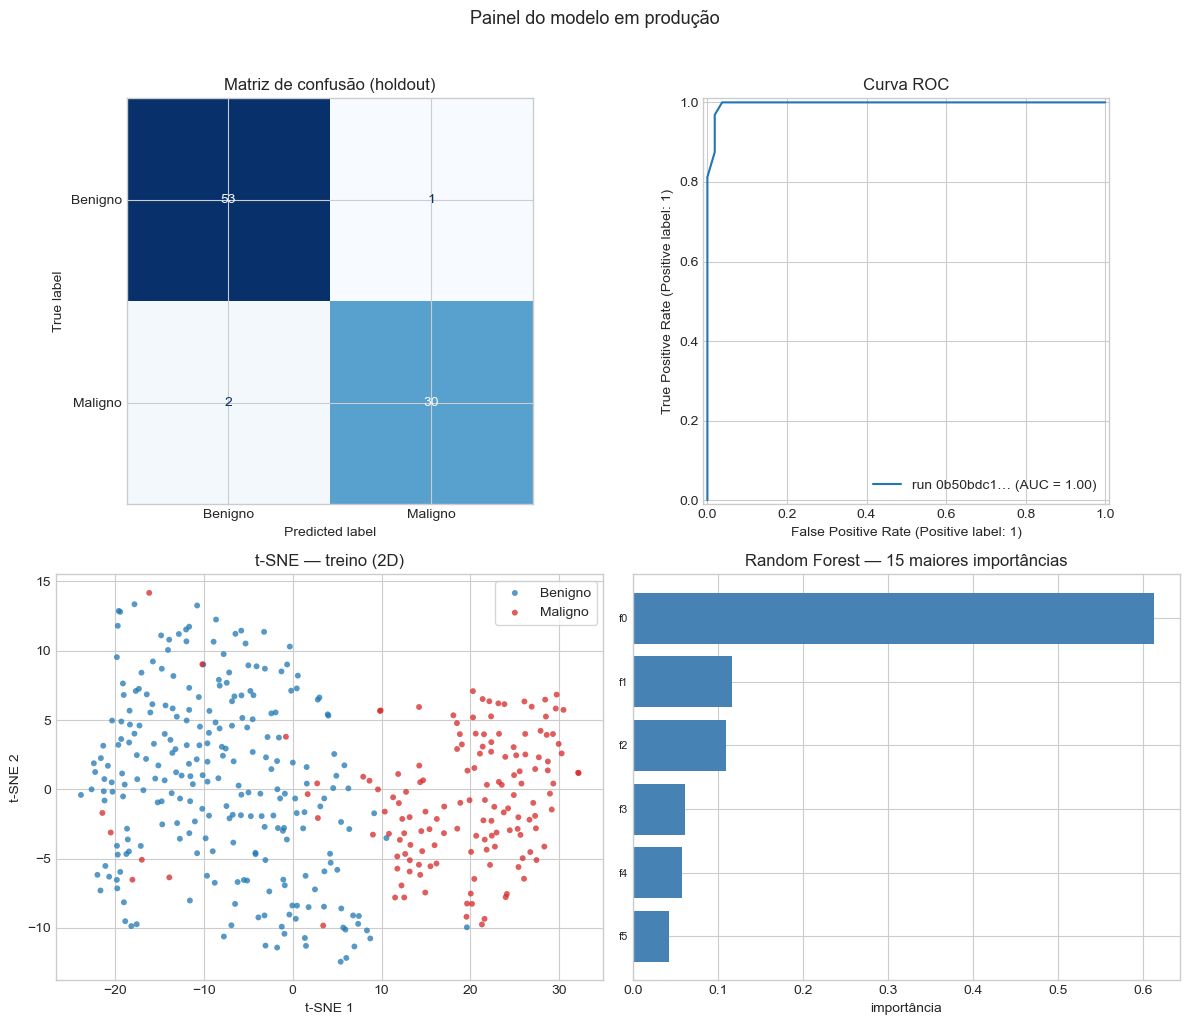

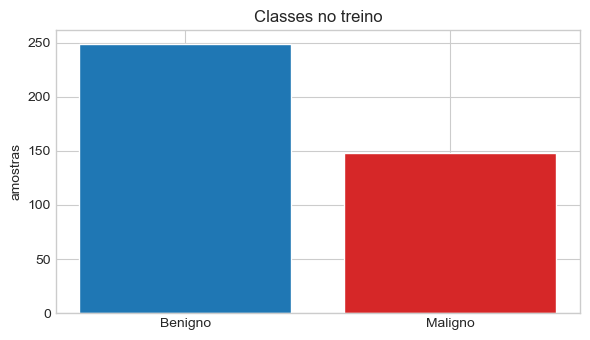

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

from breast_cancer_mlops.data_prep import TARGET_COL, project_root
from breast_cancer_mlops.model_io import load_model_bundle

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    pass

ROOT = project_root()
model, feature_names, run_id = load_model_bundle(ROOT)
X_test = pd.read_csv(ROOT / "artifacts" / "splits" / "X_test.csv")[feature_names]
y_test = pd.read_csv(ROOT / "artifacts" / "splits" / "y_test.csv")[TARGET_COL]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=["Benigno", "Maligno"],
    ax=axes[0, 0],
    cmap="Blues",
    colorbar=False,
)
axes[0, 0].set_title("Matriz de confusão (holdout)")

RocCurveDisplay.from_estimator(
    model,
    X_test,
    y_test,
    ax=axes[0, 1],
    name=f"run {run_id[:8]}…",
)
axes[0, 1].set_title("Curva ROC")

tsne_path = ROOT / "artifacts" / "exploration" / "tsne_train_2d.csv"
ax_ts = axes[1, 0]
if tsne_path.is_file():
    ts = pd.read_csv(tsne_path)
    for lab, name, c in [(0, "Benigno", "#1f77b4"), (1, "Maligno", "#d62728")]:
        m = ts[ts["diagnosis"] == lab]
        ax_ts.scatter(m["tsne_1"], m["tsne_2"], s=18, alpha=0.75, c=c, label=name, edgecolors="none")
    ax_ts.legend(loc="best", frameon=True)
    ax_ts.set_xlabel("t-SNE 1")
    ax_ts.set_ylabel("t-SNE 2")
else:
    ax_ts.text(0.5, 0.5, "Rode a seção 2.1 (t-SNE)", ha="center", va="center", transform=ax_ts.transAxes)
ax_ts.set_title("t-SNE — treino (2D)")

clf = model.named_steps.get("clf")
ax_imp = axes[1, 1]
if clf is not None and hasattr(clf, "feature_importances_"):
    imp = clf.feature_importances_
    idx = np.argsort(imp)[-15:]
    ax_imp.barh(range(len(idx)), imp[idx], color="steelblue")
    ax_imp.set_yticks(range(len(idx)))
    ax_imp.set_yticklabels([f"f{i}" for i in idx], fontsize=8)
    ax_imp.set_title("Random Forest — 15 maiores importâncias")
    ax_imp.set_xlabel("importância")
else:
    proba = model.predict_proba(X_test)[:, 1]
    ax_imp.hist(proba, bins=22, color="steelblue", edgecolor="white", alpha=0.9)
    ax_imp.set_title("P(maligno) no holdout")
    ax_imp.set_xlabel("probabilidade")

plt.suptitle("Painel do modelo em produção", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

y_train = pd.read_csv(ROOT / "artifacts" / "splits" / "y_train.csv")[TARGET_COL]
fig2, axb = plt.subplots(figsize=(6, 3.5))
vc = y_train.value_counts().reindex([0, 1]).fillna(0)
axb.bar(["Benigno", "Maligno"], vc.values, color=["#1f77b4", "#d62728"], edgecolor="white")
axb.set_title("Classes no treino")
axb.set_ylabel("amostras")
plt.tight_layout()
plt.show()


### 6.2 Streamlit com o modelo já treinado

Inicia o servidor, mostra o link e os logs do Streamlit na saída da célula. A execução fica **bloqueada** enquanto o app estiver no ar; use **Interromper** (■) para encerrar o servidor. Se rodar a célula de novo, um processo anterior ainda ativo é encerrado antes de subir outro.

In [ ]:
import atexit
import builtins
import os
import socket
import subprocess
import sys
import threading

from IPython.display import HTML, display

from breast_cancer_mlops.data_prep import project_root


def _pick_port(lo=8501, hi=8510):
    for port in range(lo, hi + 1):
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            try:
                s.bind(("127.0.0.1", port))
                return port
            except OSError:
                continue
    return 8501


def _stop_streamlit():
    p = getattr(builtins, "_mlops_st_proc", None)
    if p is None:
        return
    if p.poll() is None:
        p.terminate()
        try:
            p.wait(timeout=20)
        except subprocess.TimeoutExpired:
            p.kill()
            p.wait(timeout=10)


def _stderr_reader(proc):
    try:
        for line in iter(proc.stderr.readline, b""):
            if not line:
                break
            sys.stdout.write(line.decode(errors="replace"))
            sys.stdout.flush()
    except Exception:
        pass


ROOT = project_root()
_stop_streamlit()

port = _pick_port()
st_py = ROOT / "src" / "breast_cancer_mlops" / "streamlit_app.py"
args = [
    sys.executable,
    "-m",
    "streamlit",
    "run",
    str(st_py),
    "--server.headless",
    "true",
    "--server.port",
    str(port),
    "--browser.gatherUsageStats",
    "false",
]
_env = os.environ.copy()
_env["PYTHONPATH"] = str(ROOT / "src") + os.pathsep + _env.get("PYTHONPATH", "")
pop = dict(
    cwd=str(ROOT),
    stdout=subprocess.DEVNULL,
    stderr=subprocess.PIPE,
    env=_env,
)
if sys.platform == "win32":
    pop["creationflags"] = subprocess.CREATE_NO_WINDOW
proc = subprocess.Popen(args, **pop)
builtins._mlops_st_proc = proc
url = f"http://127.0.0.1:{port}"
builtins._mlops_st_url = url

if not getattr(builtins, "_mlops_st_atexit_registered", False):
    atexit.register(_stop_streamlit)
    builtins._mlops_st_atexit_registered = True

threading.Thread(target=_stderr_reader, args=(proc,), daemon=True).start()

display(HTML(f'<p>Streamlit: <a href="{url}" target="_blank">{url}</a></p>'))
print("Logs do processo abaixo. Interrompa esta célula (■) para encerrar o servidor.")

try:
    proc.wait()
except KeyboardInterrupt:
    _stop_streamlit()
    print("Servidor Streamlit encerrado.")


Logs do processo abaixo. Interrompa esta célula (■) para encerrar o servidor.
c:\Users\thiag\anaconda\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
